# Week 12 — Mock Coursework — SOLUTIONS: An Empirical Finance Project

**MANG2074 Financial Econometrics 1**

This notebook mirrors the structure of the assessed empirical project (3000-word style). Treat each part as a section of your report: code, results, then a written interpretation in the markdown cell provided.

**Brief.** You are a junior analyst. Produce an empirical report covering:

- **Part A — Data and stylised facts**: construct returns, descriptive statistics, normality.
- **Part B — Asset pricing**: a CAPM study of General Electric (2002–2018) with full diagnostics and a 2008 structural-break test.
- **Part C — Forecasting**: Box–Jenkins ARMA modelling and a 12-month forecast of UK house-price growth.
- **Part D — Risk**: GARCH modelling of GBP/USD and a 1% one-day parametric VaR for a £5m position.

**Data**: `../data/capm.csv`, `../data/ukhp.csv`, `../data/currencies.csv`.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import (het_breuschpagan, het_white,
                                          acorr_breusch_godfrey, linear_reset, het_arch)
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from arch import arch_model
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

capm = pd.read_csv('../data/capm.csv', index_col=0, parse_dates=True)
hp = pd.read_csv('../data/ukhp.csv', index_col=0, parse_dates=True).asfreq('MS')
fx = pd.read_csv('../data/currencies.csv', index_col=0, parse_dates=True)
print('loaded:', capm.shape, hp.shape, fx.shape)

loaded: (194, 6) (327, 1) (7142, 3)


## Part A — Data and stylised facts

In [2]:
capm['erge'] = 100 * np.log(capm['GE']).diff() - capm['USTB3M'] / 12
capm['ersandp'] = 100 * np.log(capm['SANDP']).diff() - capm['USTB3M'] / 12
hp['dhp'] = 100 * hp['Average House Price'].pct_change()
fx['rgbp'] = 100 * np.log(fx['GBP']).diff()

series = {'GE excess ret (m)': capm['erge'].dropna(),
          'S&P excess ret (m)': capm['ersandp'].dropna(),
          'UK house growth (m)': hp['dhp'].dropna(),
          'GBP/USD ret (d)': fx['rgbp'].dropna()}

rows = {}
for name, s in series.items():
    jb, jb_p, _, _ = jarque_bera(s)
    rows[name] = {'n': len(s), 'mean': s.mean(), 'std': s.std(),
                  'skew': s.skew(), 'ex.kurt': s.kurtosis(),
                  'JB': jb, 'JB p': jb_p}
print(pd.DataFrame(rows).T.round(3))


                          n   mean    std   skew  ex.kurt         JB   JB p
GE excess ret (m)     193.0 -0.605  7.755 -0.763    3.096     90.086  0.000
S&P excess ret (m)    193.0  0.351  4.135 -0.933    2.426     71.293  0.000
UK house growth (m)   326.0  0.432  1.119 -0.082    0.636      5.384  0.068
GBP/USD ret (d)      7141.0  0.003  0.421  0.813   12.893  50171.502  0.000


**Interpretation (model answer).** All four return series are non-normal at any conventional significance level, with the daily sterling series the most extreme (excess kurtosis far above zero — fat tails) and GE's monthly excess returns both negatively skewed and leptokurtic, reflecting its near-collapse in 2008–09. House-price growth has a high positive mean per unit of risk but is an appraisal-smoothed index. The non-normality flags that (i) exact normal-theory inference is approximate at best, and (ii) any risk model assuming Gaussian tails (Part D) needs scrutiny.

## Part B — CAPM study of General Electric

### B1 — Estimation and hypothesis tests

In [3]:
df = capm.dropna()
ge = smf.ols('erge ~ ersandp', df).fit()
print(ge.summary())
print()
print("(ii) H0: beta = 1")
print(ge.t_test('ersandp = 1'))


                            OLS Regression Results                            
Dep. Variable:                   erge   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     187.4
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           3.56e-30
Time:                        01:37:18   Log-Likelihood:                -602.70
No. Observations:                 193   AIC:                             1209.
Df Residuals:                     191   BIC:                             1216.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0680      0.399     -2.676      0.0

**Interpretation.** $\hat\beta \approx 1.32$ (t ≈ 13.7): (i) $\beta=0$ is rejected — GE carries substantial market risk; (ii) $\beta=1$ is also rejected (t ≈ 3.3) — GE is significantly *more* market-sensitive than average, consistent with its industrial-cum-financial conglomerate profile; (iii) $\hat\alpha \approx -1.07\%$ per month and **significant** (p ≈ 0.008): over 2002–2018 GE *underperformed* its CAPM benchmark by roughly 12–13% per year — an economically enormous negative alpha capturing the firm's slow-motion decline. $R^2 \approx 0.50$: half of GE's variance is market-driven.

### B2 — Diagnostic battery

In [4]:
X = ge.model.exog
bp = het_breuschpagan(ge.resid, X)
wh = het_white(ge.resid, X)
bg = acorr_breusch_godfrey(ge, nlags=12)
jb = jarque_bera(ge.resid)
rs = linear_reset(ge, power=3, use_f=True)

diag = pd.DataFrame({
    'statistic': [bp[0], wh[0], durbin_watson(ge.resid), bg[0], jb[0], float(rs.fvalue)],
    'p-value': [bp[1], wh[1], np.nan, bg[1], jb[1], float(rs.pvalue)]},
    index=['Breusch-Pagan', 'White', 'Durbin-Watson', 'Breusch-Godfrey(12)',
           'Jarque-Bera (resid)', 'RESET'])
print(diag.round(4))

# Remedy for the BG rejection: Newey-West HAC standard errors
ge_nw = smf.ols('erge ~ ersandp', df).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
print("\nNewey-West (HAC, 6 lags) inference:")
print(pd.DataFrame({'coef': ge_nw.params, 'NW se': ge_nw.bse,
                    't': ge_nw.tvalues, 'p': ge_nw.pvalues}).round(4))


                     statistic  p-value
Breusch-Pagan           3.1250   0.0771
White                   7.3889   0.0249
Durbin-Watson           1.8250      NaN
Breusch-Godfrey(12)    30.4721   0.0024
Jarque-Bera (resid)    55.1943   0.0000
RESET                   2.3154   0.1015

Newey-West (HAC, 6 lags) inference:
            coef   NW se       t       p
Intercept -1.068  0.4495 -2.3758  0.0175
ersandp    1.320  0.1812  7.2827  0.0000


**Interpretation.** Heteroscedasticity: BP is borderline (p ≈ 0.08), White does not reject — mild at worst. **Autocorrelation: Breusch–Godfrey rejects (p ≈ 0.002)** despite DW ≈ 1.8 (DW only sees lag 1 — exactly why BG is preferred), so default OLS standard errors are unreliable. Residual normality is rejected (JB ≈ 55; crisis outliers). RESET is fine (p ≈ 0.10) — the linear form is adequate. **Remedy**: Newey–West HAC SEs. The headline conclusions survive: beta remains overwhelmingly significant and alpha remains significantly negative (p ≈ 0.018). Reporting the HAC column is the defensible choice for the write-up.

### B3 — Structural stability

In [5]:
pre = smf.ols('erge ~ ersandp', df[:'2007-12-31']).fit()
post = smf.ols('erge ~ ersandp', df['2008-01-01':]).fit()

k, T = 2, ge.nobs
F = ((ge.ssr - (pre.ssr + post.ssr)) / k) / ((pre.ssr + post.ssr) / (T - 2 * k))
p = stats.f.sf(F, k, T - 2 * k)
print(f"beta pre-2008  = {pre.params['ersandp']:.3f}")
print(f"beta post-2008 = {post.params['ersandp']:.3f}")
print(f"Chow F = {F:.3f}, F(2, {int(T-2*k)}) p-value = {p:.4f}")


beta pre-2008  = 0.848
beta post-2008 = 1.490
Chow F = 5.234, F(2, 189) p-value = 0.0061


**Interpretation.** The Chow test rejects parameter constancy decisively (F ≈ 5.2, p ≈ 0.006): GE's beta jumps from ≈ 0.85 pre-crisis to ≈ 1.49 after January 2008. The economics is well documented — by the mid-2000s GE Capital had made GE half a financial company; when the financial system cracked, GE's market sensitivity re-rated to that of a levered financial. A single full-sample beta of 1.32 is therefore an average of two different firms; for risk-management use, the post-2008 beta is the relevant one.

**Part B write-up (model answer, ~200 words).** We estimate the CAPM for GE on monthly excess returns, 2002–2018. The market beta is 1.32 (Newey–West t ≈ 7.3), significantly above one, so GE amplified market movements over the sample. The alpha of −1.07% per month is statistically significant (HAC p ≈ 0.018) and economically large (≈ −12% per annum): GE destroyed value relative to its systematic-risk benchmark. Diagnostics show why robust inference matters: Breusch–Godfrey rejects no-autocorrelation (p ≈ 0.002), so we report HAC standard errors throughout; residuals are non-normal (JB ≈ 55) due to crisis outliers, tolerable at T = 193 by central-limit arguments; RESET finds no neglected nonlinearity. A Chow test at January 2008 rejects stability (p ≈ 0.006), with beta rising from 0.85 to 1.49 — consistent with GE Capital transforming the firm's risk profile through the crisis. Limitations: a single-factor model omits size/value/momentum factors; betas estimated from monthly data are noisy; and the alpha partly reflects firm-specific news (dividend cuts, accounting concerns) that no risk model prices.

## Part C — Forecasting UK house-price growth

### C1 — Identification and estimation

ADF on dhp: stat = -3.272, 5% cv = -2.871, p = 0.0162 -> stationary


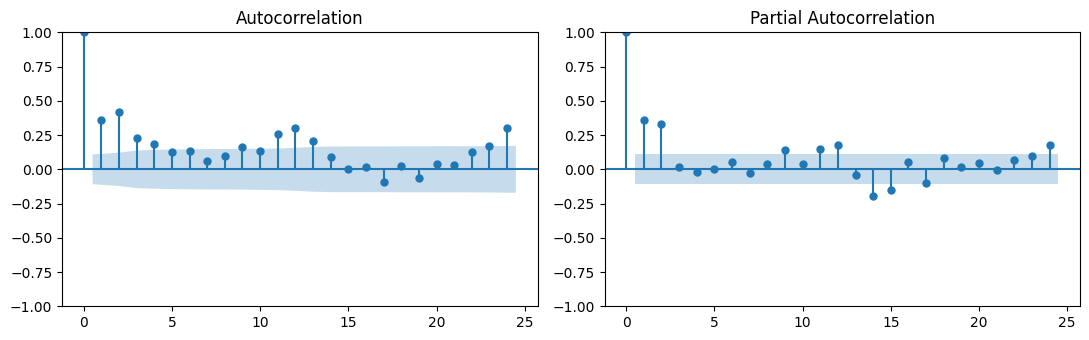

              AIC     BIC
ARMA(1,0)  958.79  970.15
ARMA(2,0)  922.46  937.61
ARMA(1,1)  933.42  948.57
ARMA(2,1)  924.41  943.34
ARMA(2,2)  926.24  948.96

AR(2) residual Ljung-Box:
    lb_stat  lb_pvalue
6    0.9934     0.9108
12  34.3853     0.0002
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4275      0.128      3.339      0.001       0.177       0.679
ar.L1          0.2361      0.044      5.331      0.000       0.149       0.323
ar.L2          0.3340      0.043      7.851      0.000       0.251       0.417
sigma2         0.9666      0.066     14.622      0.000       0.837       1.096


In [6]:
dhp = hp['dhp'].dropna()

stat, pval, _, _, crit, _ = adfuller(dhp)
print(f"ADF on dhp: stat = {stat:.3f}, 5% cv = {crit['5%']:.3f}, p = {pval:.4f} -> stationary")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(dhp, lags=24, ax=axes[0]); plot_pacf(dhp, lags=24, ax=axes[1])
plt.tight_layout(); plt.show()

cands = {f"ARMA({p},{q})": ARIMA(dhp, order=(p, 0, q)).fit()
         for p, q in [(1, 0), (2, 0), (1, 1), (2, 1), (2, 2)]}
print(pd.DataFrame({k: {'AIC': v.aic, 'BIC': v.bic} for k, v in cands.items()}).T.round(2))

best = cands['ARMA(2,0)']
lb = sm.stats.acorr_ljungbox(best.resid, lags=[6, 12], model_df=2)
print()
print("AR(2) residual Ljung-Box:"); print(lb.round(4))
print(best.summary().tables[1])


**Interpretation.** `dhp` is stationary (ADF −3.27 < −2.87, p ≈ 0.016). The correlogram shows a decaying ACF with the PACF cutting off after lag 2 — the AR(2) signature — and BIC confirms AR(2) over the alternatives. Both AR coefficients are positive and significant ($\hat\phi_1 ≈ 0.24$, $\hat\phi_2 ≈ 0.33$): persistent momentum. Residuals are white at short lags (Ljung–Box(6) p ≈ 0.91) but reject at 12 lags — residual **seasonality** at the annual lag, which we note as a caveat (seasonal dummies or a SARMA term would polish it) while retaining the AR(2) for the non-seasonal dynamics.

### C2 — Forecast

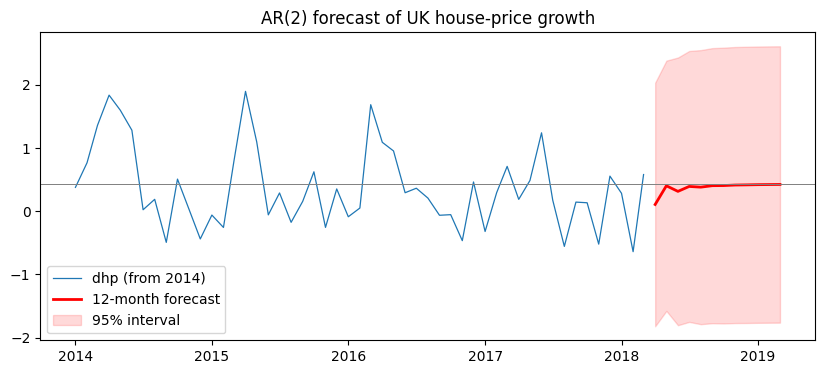

2018-04-01    0.108
2018-05-01    0.403
2018-06-01    0.315
2018-07-01    0.393
2018-08-01    0.382
2018-09-01    0.405
2018-10-01    0.407
2018-11-01    0.415
2018-12-01    0.418
2019-01-01    0.421
2019-02-01    0.423
2019-03-01    0.424
Freq: MS, Name: predicted_mean, dtype: float64


In [7]:
fc = best.get_forecast(12)
mean_fc = fc.predicted_mean
ci = fc.conf_int()

plt.figure(figsize=(10, 4))
plt.plot(dhp['2014':], lw=0.9, label='dhp (from 2014)')
plt.plot(mean_fc, 'r-', lw=2, label='12-month forecast')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='red', alpha=0.15,
                 label='95% interval')
plt.axhline(dhp.mean(), color='grey', lw=0.7)
plt.legend(); plt.title('AR(2) forecast of UK house-price growth')
plt.show()
print(mean_fc.round(3))


**Interpretation / Part C write-up (model answer, ~150 words).** UK monthly house-price growth is stationary and strongly autocorrelated; an AR(2) chosen by BIC fits with significant momentum at both lags and residuals that are white at short lags (untreated annual seasonality remains at lag 12). The 12-month forecast starts from current conditions and reverts geometrically towards the unconditional mean of ≈ 0.43% per month (≈ 5.3% annualised) — the hallmark of a stationary process: the model's long-run forecast *is* the historical mean, and its value lies in the transition path and the honest 95% bands (roughly ±2pp at 12 months, wide enough to include negative growth). For a lender, the practical content is the short horizon: next-quarter growth inherits the recent momentum; beyond a year, the model says "expect the average, with substantial uncertainty". Caveats: the Nationwide index is smoothed (momentum partly mechanical), seasonality is untreated, and the AR structure cannot anticipate policy or rate shocks.

## Part D — GARCH risk model for sterling

### D1 — ARCH effects and GARCH estimation

ARCH-LM(5): 253.0, p = 1.25e-52  -> strong ARCH effects



GARCH(1,1) normal: alpha = 0.0348, beta = 0.9611, persistence = 0.9959
GARCH(1,1) t:      alpha = 0.0281, beta = 0.9719, persistence = 1.0000, nu = 3.24
log-likelihood: normal -3301.0 vs t -2886.3


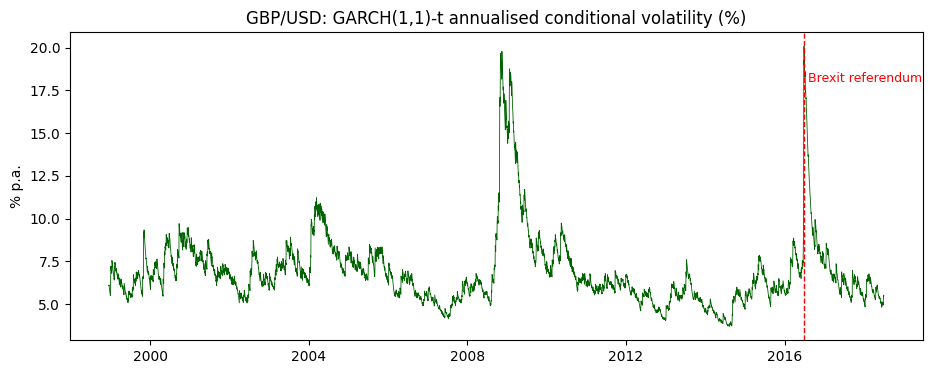

In [8]:
rgbp = fx['rgbp'].dropna()

lm, lm_p, _, _ = het_arch(rgbp - rgbp.mean(), nlags=5)
print(f"ARCH-LM(5): {lm:.1f}, p = {lm_p:.3g}  -> strong ARCH effects")

g_n = arch_model(rgbp, p=1, q=1).fit(disp='off')
g_t = arch_model(rgbp, p=1, q=1, dist='t').fit(disp='off')

print(f"\nGARCH(1,1) normal: alpha = {g_n.params['alpha[1]']:.4f}, beta = {g_n.params['beta[1]']:.4f}, "
      f"persistence = {g_n.params['alpha[1]'] + g_n.params['beta[1]']:.4f}")
print(f"GARCH(1,1) t:      alpha = {g_t.params['alpha[1]']:.4f}, beta = {g_t.params['beta[1]']:.4f}, "
      f"persistence = {g_t.params['alpha[1]'] + g_t.params['beta[1]']:.4f}, nu = {g_t.params['nu']:.2f}")
print(f"log-likelihood: normal {g_n.loglikelihood:.1f} vs t {g_t.loglikelihood:.1f}")

plt.figure(figsize=(11, 4))
plt.plot(np.sqrt(252) * g_t.conditional_volatility, lw=0.6, color='darkgreen')
plt.axvline(pd.Timestamp('2016-06-24'), color='red', ls='--', lw=1)
plt.text(pd.Timestamp('2016-08-01'), 18, 'Brexit referendum', color='red', fontsize=9)
plt.title('GBP/USD: GARCH(1,1)-t annualised conditional volatility (%)')
plt.ylabel('% p.a.'); plt.show()


**Interpretation.** ARCH effects are overwhelming, as expected for daily FX. The normal-error GARCH gives persistence ≈ 0.996 — high but stationary, implying a volatility half-life of several months. The Student-t version fits far better (likelihood gain in the hundreds; $\hat\nu \approx 3.2$ — very fat conditional tails) but pushes persistence to the IGARCH boundary (≈ 1.0): with $\hat\alpha+\hat\beta \approx 1$, the unconditional variance is undefined and long-horizon variance forecasts do not mean-revert — a caution flag for anything beyond short-horizon use. The conditional-vol plot spikes exactly where it should: 2008–09 and, spectacularly, around the June 2016 Brexit referendum (the largest one-day sterling move in the floating era).

### D2 — Value-at-Risk

In [9]:
position = 5_000_000   # GBP 5m

for res, dist in [(g_n, 'normal'), (g_t, 'Student-t')]:
    f1 = res.forecast(horizon=1, reindex=False)
    sigma = float(np.sqrt(f1.variance.values[-1, 0]))
    mu = res.params['mu']
    if dist == 'normal':
        q = stats.norm.ppf(0.01)
    else:
        nu = res.params['nu']
        q = stats.t.ppf(0.01, nu) * np.sqrt((nu - 2) / nu)
    var = -(mu + q * sigma) * position / 100
    print(f"{dist:9s}: sigma_fc = {sigma:.4f}%, q_0.01 = {q:.3f}, 1% 1-day VaR = GBP {var:,.0f}")


normal   : sigma_fc = 0.3192%, q_0.01 = -2.326, 1% 1-day VaR = GBP 37,191


Student-t: sigma_fc = 0.3443%, q_0.01 = -2.649, 1% 1-day VaR = GBP 45,703


**Interpretation / Part D write-up (model answer, ~150 words).** Daily sterling returns display massive ARCH effects; a GARCH(1,1) captures the clustering with persistence ≈ 0.996, and Student-t innovations ($\nu ≈ 3.2$) are decisively preferred by the likelihood — sterling's conditional distribution is heavy-tailed, with Brexit the canonical example of a move a Gaussian model cannot rationalise. The 1% one-day VaR on a £5m position, using tomorrow's volatility forecast, is materially **larger under t innovations than under normality** (the t quantile is fatter); we recommend the desk adopt the t-based figure, because the normal VaR would be breached more than 1% of the time precisely in stressed conditions. Caveats: the t model sits at the IGARCH boundary, so we restrict it to short-horizon risk; parametric VaR depends on the specification (historical-simulation cross-checks advisable); and a single-day 1% VaR says nothing about the *size* of losses beyond it (expected shortfall would).

## Executive summary (model answer)

**Asset pricing.** GE's CAPM beta over 2002–2018 is 1.32 (significantly above 1) and unstable: 0.85 pre-crisis vs 1.49 after January 2008 (Chow p ≈ 0.006). Its alpha of −1.07% per month (HAC p ≈ 0.018) marks sustained underperformance. **Forecasting.** UK house-price growth is stationary, momentum-driven and well described by an AR(2); 12-month forecasts revert to ≈ 0.4% per month with wide bands — short-horizon forecasts informative, long-horizon ones are the mean. **Risk.** Sterling volatility clusters strongly; a GARCH(1,1)-t model (ν ≈ 3.2) is preferred, and the t-based 1% one-day VaR on £5m exceeds the Gaussian figure — we recommend the heavier-tailed number for limit-setting. Across all three studies, the recurring lesson is that diagnostics (autocorrelation-robust SEs, break tests, fat-tailed innovations) change headline numbers by economically material amounts.